In [2]:
from typing import Callable
from pathlib import Path

from numpy.typing import NDArray
import numpy as np

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask

import darksun as ds


ds.show.set_figures_darkbkg()

In [3]:
#BASEPATH: str = '...'
BASEPATH: str = '/mnt/d/PhD_AASS/Coding/Images_fits'
MASK_FITS: str = "wfm_mask_NTHT_20260129_CORRECTED.fits"

UPS_X: int = 5
UPS_Y: int = 1
wfm = codedmask(f'{BASEPATH}/{MASK_FITS}', UPS_X, UPS_Y)

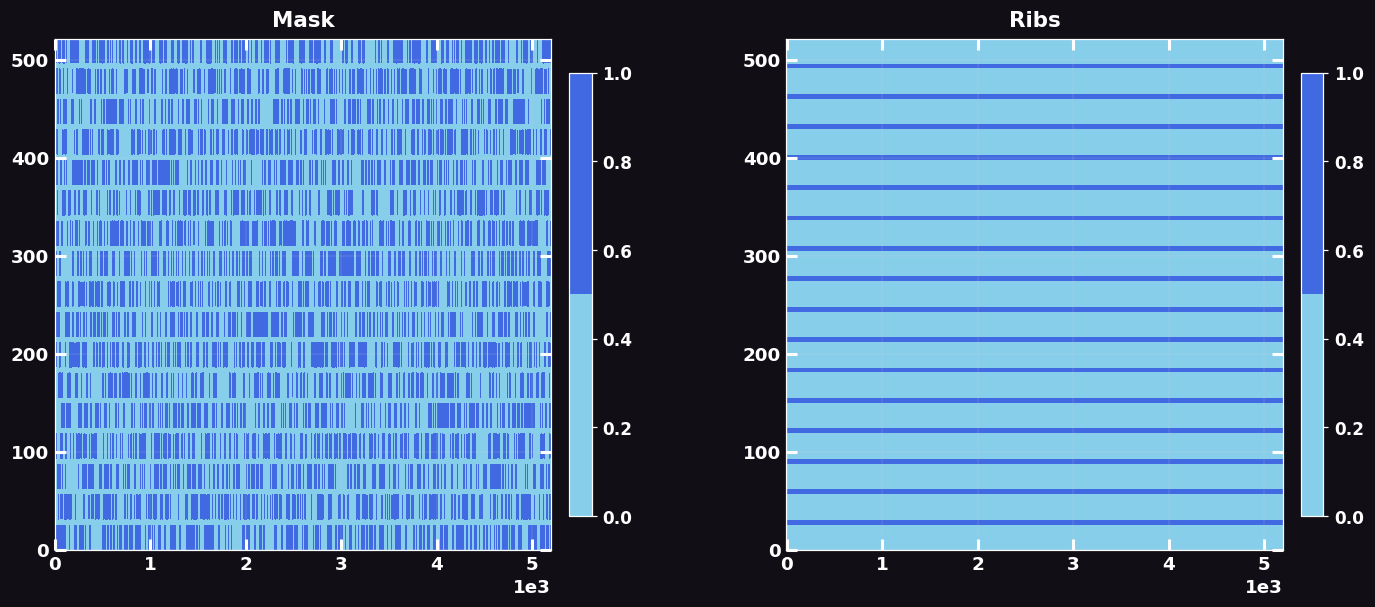

In [4]:
from matplotlib.colors import ListedColormap as lc

def get_ribs(
    camera: CodedMaskCamera,
    ely_dim: float = 13.0,
    n_ely: int = 17,
    ribsy_dim: float = 2.5,
) -> NDArray:
    """Creates a blueprint of the mask ribs."""
    px_dim_y = camera.specs.mask_deltay / camera.upscale_f.y
    n_ely_px = int(ely_dim / px_dim_y)
    n_riby_px = int(ribsy_dim / px_dim_y)
    base = np.zeros_like(camera.mask, dtype=int)
    for idx in range(n_ely):
        base[(idx + 1) * (n_ely_px + n_riby_px) - n_riby_px : (idx + 1) * (n_ely_px + n_riby_px), :] += 1
    return base



ribs: NDArray = get_ribs(wfm)

img_kwargs={
    'aspect': wfm.shape_detector[1] / wfm.shape_detector[0],
    'cmap': lc(["SkyBlue", "RoyalBlue"]),
}
dmaps=(
    ds.map4image(
        wfm.mask,
        title='Mask',
        img_kwargs=img_kwargs,
    ),
    ds.map4image(
        ribs,
        title='Ribs',
        img_kwargs=img_kwargs,
    ),
    #ds.map4image(
    #    wfm.mask + ribs,
    #    title='mask + ribs',
    #    img_kwargs=img_kwargs,
    #),
)
ds.image_plot(
    dmaps=dmaps,
    ncols=len(dmaps),
)


In [ ]:
from bloodmoon.images import fshift

def show_arr(
    arr: NDArray | tuple[NDArray, ...],
    title: str | tuple[str, ...],
) -> None:
    """Plots the given 2D array as image."""
    _arr = (arr,) if isinstance(arr, np.ndarray) else arr
    _title = (title,) if isinstance(title, str) else title
    img_kwargs={
    'aspect': _arr[0].shape[1] / _arr[0].shape[0],
    #'cmap': lc(['DeepPink', 'RoyalBlue']),  # lc(["SkyBlue", "Orange"])
    }
    dmaps = tuple(
        ds.map4image(a, title=t, img_kwargs=img_kwargs)
        for a, t in zip(_arr, _title)
    )
    ncols = np.ceil(np.sqrt(len(dmaps)))
    nrows = np.round(np.sqrt(len(dmaps)), 0)
    ds.image_plot(
        dmaps=dmaps,
        ncols=int(ncols),
        nrows=int(nrows),
    )
    return None


arr: NDArray = np.array(
    [
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
    ]
)

In [75]:
arr_mask_pos = (arr > 0) & (fshift(arr, -1, 0) > 0)
pos = arr * arr_mask_pos

arr_mask_diff_y = (arr - fshift(arr, -1, 0)) > 0
pos_diff_y = arr * arr_mask_diff_y

arr_mask_diff_x = (arr > 0) & (fshift(arr, 0, 1) > 0)
pos_diff_x = pos_diff_y * arr_mask_diff_x

cutted_mask = (arr - pos_diff_x) > 0
cutted = arr * cutted_mask

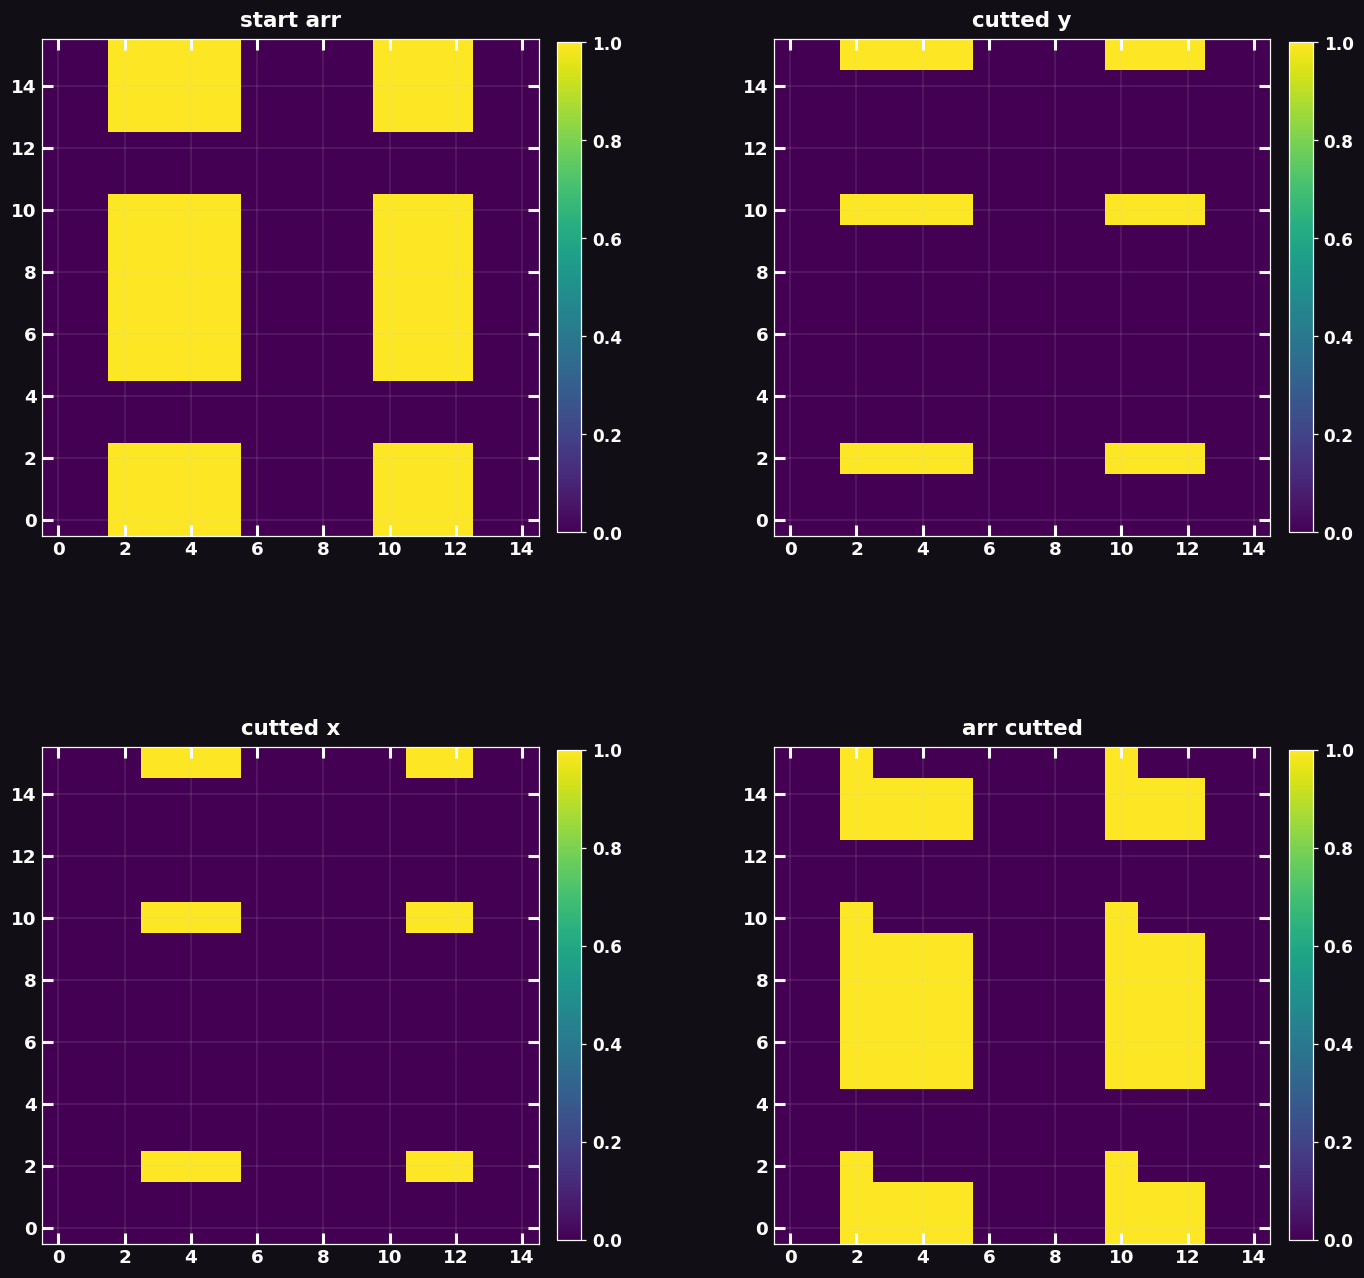

In [76]:
arrs = (
    arr, pos_diff_y, pos_diff_x, cutted,
)
titles = (
    'start arr', 'cutted y', 'cutted x', 'arr cutted',
)
show_arr(arrs, titles)

In [80]:
from dataclasses import dataclass

@dataclass
class RibsStructure:
    """
    Container for camera mask ribs structure specifics in [mm].
    """
    ribs_dim: float
    supp_heigth: float
    supp_equiv_thickness: float

def get_ribs_struct(
    ribs_dim: float = 2.5,
    supp_heigth: float = 1.75,
    supp_equiv_thickness: float = 0.25,
) -> RibsStructure:
    ribs = RibsStructure(
        ribs_dim=ribs_dim,
        supp_heigth=supp_heigth,
        supp_equiv_thickness=supp_equiv_thickness,
    )
    return ribs

In [107]:
from bloodmoon.coords import shift2angle
from bloodmoon.images import _erosion
from bloodmoon.optim import apply_vignetting as std_vignetting

def apply_vignetting(
    camera: CodedMaskCamera,
    shadowgram: NDArray,
    shift_x: float,
    shift_y: float,
    ribs_struct: RibsStructure,
) -> NDArray:
    """
    Apply vignetting effects to a shadowgram based on source position.
    """
    #def correct_proj_eroded_dist(dist: float, bin_dim: float) -> float:
    #    """Eroded distance correction for pixel discrete domain."""
    #    angle = np.arctan(dist / camera.specs.mask_detector_distance)
    #    proj = camera.specs.mask_thickness * np.tan(angle)
    #    shift_px = dist / bin_dim
    #    bin_erosion_start = (1.0 - abs(shift_px - int(shift_px))) * bin_dim
    #    return proj + np.sign(proj) * bin_erosion_start

    def apply_ribs_vignetting(sg: NDArray, step: float, cut: float) -> NDArray:
        """Applies camera mask ribs structure correction for vignetting."""
        eroded = _erosion(sg.T, step, cut)
        return eroded.T

    # apply vignetting for standard mask structure
    sg_vignetted = std_vignetting(camera, shadowgram, shift_x, shift_y)

    # correct vignetted sg for the ribs structure
    # - compute critical angle for correction activation
    #
    #                    \ 
    #                  <-->  
    #                  _t__\     
    #                 |   | \  crit_angle
    #                 |   |__\
    #              h  |   |   \      |      p = 0.5 * (L - t) 
    #                 |   |    \     |      crit_angle = atan(p / h)
    #                 |   |     \    |
    #                 |   |      \   |
    #         --------------------\__|
    #         <------------------> \ |  crit_angle
    #                    p <----->  \|    
    #                                |
    #
    struct_eff_base = 0.5 * (ribs_struct.ribs_dim - ribs_struct.supp_equiv_thickness)
    crit_angle_y = abs(np.rad2deg(np.atan(struct_eff_base / ribs_struct.supp_heigth)))
    angle_y = shift2angle(camera, shift_y)
    # - compute ribs structure effect
    if (abs(angle_y) > crit_angle_y):
        px_dim_y = camera.specs.mask_deltay / camera.upscale_f.y
        erosion_dist_y = ribs_struct.supp_heigth * np.tan(np.deg2rad(abs(angle_y))) - struct_eff_base
        #erosion_px_y = np.sign(angle_y) * erosion_dist_y * camera.upscale_f.y / camera.specs.mask_deltay
        #dist_y = correct_proj_eroded_dist(erosion_dist_y, px_dim_y)
        print(f'Pixel erosion from ribs: {erosion_dist_y / px_dim_y}')
        sg_corrected = apply_ribs_vignetting(sg_vignetted, px_dim_y, np.sign(angle_y) * erosion_dist_y)
    else:
        sg_corrected = sg_vignetted

    return sg_corrected

Pixel erosion from ribs: 1.2499999999999996
Same sg: False



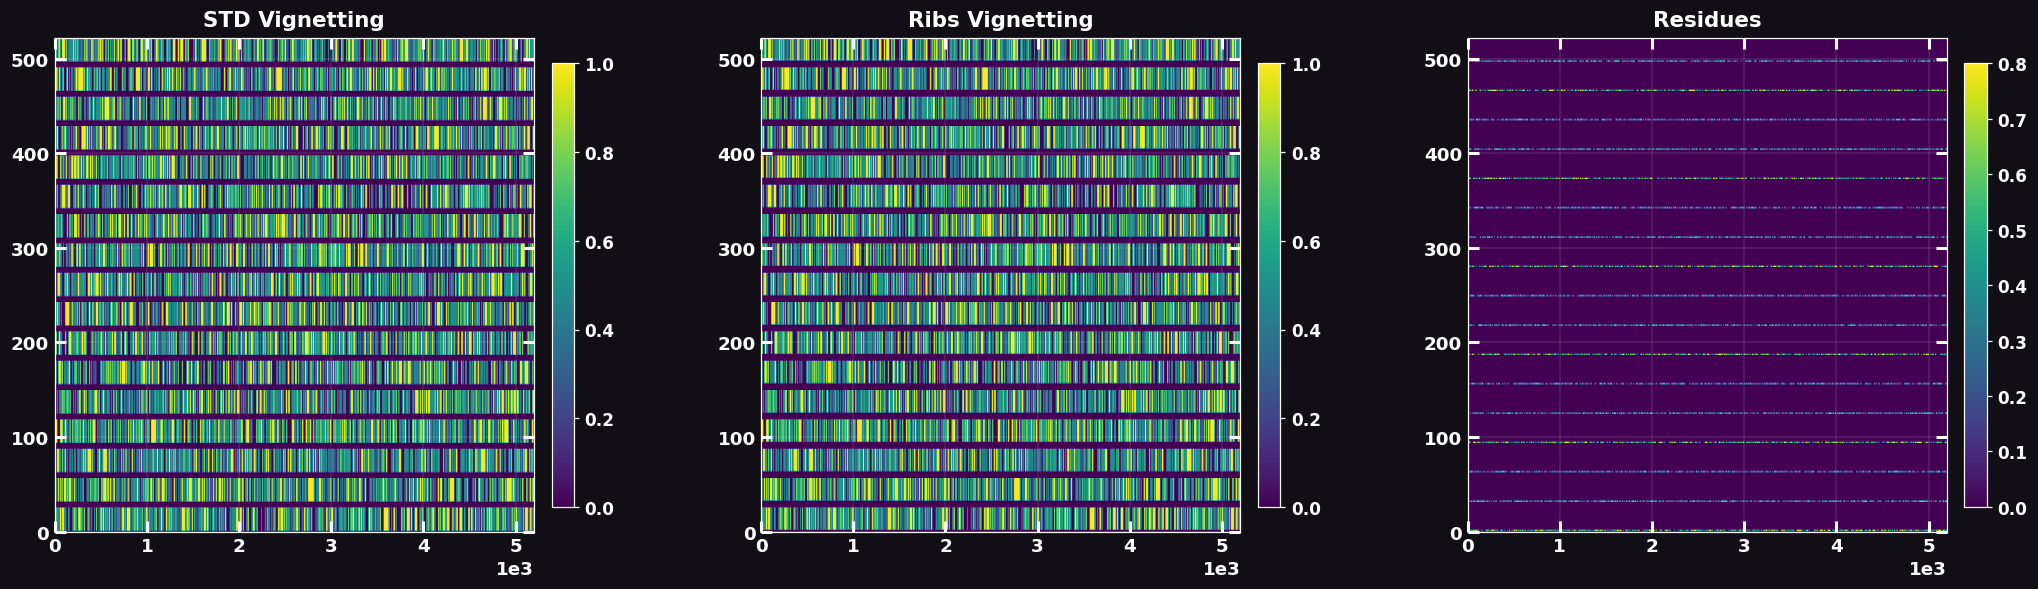

In [116]:
from bloodmoon.coords import angle2shift

angle_x, angle_y = 0.0, 45


sx, sy = map(lambda x: angle2shift(wfm, x), (angle_x, angle_y))
std_vignetted = std_vignetting(wfm, wfm.mask, sx, sy)
ribs_vignetted = apply_vignetting(wfm, wfm.mask, sx, sy, get_ribs_struct())


img_kwargs={
    'aspect': wfm.shape_detector[1] / wfm.shape_detector[0],
}
dmaps=(
    ds.map4image(
        std_vignetted,
        title='STD Vignetting',
        img_kwargs=img_kwargs,
    ),
    ds.map4image(
        ribs_vignetted,
        title='Ribs Vignetting',
        img_kwargs=img_kwargs,
    ),
    ds.map4image(
        std_vignetted - ribs_vignetted,
        title='Residues',
        img_kwargs=img_kwargs,
    ),
)

print(
    f'Same sg: {np.allclose(std_vignetted, ribs_vignetted)}\n'
)

ds.image_plot(
    dmaps=dmaps,
    ncols=len(dmaps),
)